In [18]:
from FastBEMT.Propeller import Propeller
from FastBEMT.JobParameters import LowFidelityParameters
from FastBEMT.Plotter import Plotter
from FastBEMT.DataLoader import *
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
plt.style.use(['science', 'no-latex'])

In [19]:
# prop_name, blade_dict = load_propeller_dict('SignedStress/run_001/Pareto20')[0]
prop_name, blade_dict = load_propeller_dict('10x7E')[0]

In [20]:
params = LowFidelityParameters(
    rpm=7000,
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
    n_blades=blade_dict['n_blades'],
    p_ref=2e-5,
    revolutions=5,
    num_obs_times_per_rev=100,
    device='cuda'
)

In [21]:
nx, ny = 26, 26
size = 5

In [22]:
x_range = np.linspace(-size, size, nx)
y_range = np.linspace(0, size, ny)
X, Y = np.meshgrid(x_range, y_range)
Z = np.zeros_like(X) 

r_observers = np.stack([X.flatten(), Y.flatten(), Z.flatten()], axis=1)

propeller = Propeller(
    geometry=blade_dict,
    params=params,
)

propeller.run_bemt(v_inf=0.0)

In [23]:
thrust, _torque, ct, cq = propeller.compute_total_forces()
figure_of_merit = np.sqrt(2 / np.pi) * ct**1.5 / 2 / np.pi / cq

In [24]:
figure_of_merit

np.float64(0.6618985745970318)

In [25]:
propeller.run_aeroacoustics(observer_positions=r_observers,
        lt=1,
        i=1e-3,
        alpha_stall=15,
        keep_bpm_components=False)

propeller.postprocess()

[CUDA TIMING] TorchCompactAcousticSourceArray.__init__: 255.256 ms
[CUDA TIMING] BPM.__init__: 0.939 ms
[CUDA TIMING] get_observer_times: 58.970 ms
[CUDA TIMING] calculate_f1a_pressure: 327.865 ms
[CUDA TIMING] combine_sources (F1A): 99.847 ms
[CUDA TIMING] _perform_spectral_analysis_torch: 343.814 ms
[CUDA TIMING] BPM.run_forward_bpm: 2485.584 ms
[CUDA TIMING] combine_sources_bpm: 11.624 ms


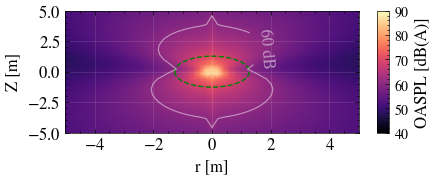

In [26]:
plotter = Plotter(propeller)
plotter.plot_acoustic_map(
    grid_size=nx,
    domain_size=size,
    figsize=(4.5, 2),
    cmap='magma',
    show_contours=True,
    save_path='../Figures/acoustic_map10x7E.pdf'
)